In [1]:
import os
os.environ["PATH"] = os.path.expanduser("~/texlive/bin/x86_64-linux") + ":" + os.environ["PATH"]

import numpy as np
import matplotlib.pyplot as plt
import csiborgtools
import scienceplots

from hmf import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_rusty)

In [2]:
f = "/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_INNER_N128_DES_V2/resimulations/step_0/output/groups_001/fof_subhalo_tab_001.hdf5"
# reader = csiborgtools.read.CSiBORG3Catalogue(0, 0, paths, fpath_override=f, boxsize=340.5)
# reader = csiborgtools.read.CSiBORG3Catalogue(0, 0, paths, fpath_override=f, boxsize=340.5)

In [3]:
# fname = "/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_MULTIBIN_N256_DES_V2_future256/step_0/output/groups_135/fof_subhalo_tab_135.hdf5"
# reader = csiborgtools.read.CSiBORG3Catalogue(0, 0, paths, fpath_override=fname)


bin_edges = 10**np.arange(13, 16, 0.2)

a = np.asarray([1.0, 2.0, 5.0, 10.0])
z = 1.0 / a - 1.0


data = []

for i in range(1, len(a) + 1):
    fname = f"/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_MULTIBIN_N256_DES_V2_future256/step_0/output/groups_{i:03d}/fof_subhalo_tab_{i:03d}.hdf5"
    reader = csiborgtools.read.CSiBORG3Catalogue(0, 0, paths, fpath_override=fname)
    x, y, ey = reader.halo_mass_function(bin_edges, mass_key="Group_M_Crit200", volume=681**3)
    data.append((y, ey)

SyntaxError: incomplete input (3076355517.py, line 17)

In [15]:
fname = "/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_MULTIBIN_N256_DES_V2/N256_far_future/step_0/output/groups_006/fof_subhalo_tab_006.hdf5"
print(fname)
reader = csiborgtools.read.CSiBORG3Catalogue(0, 0, paths, fpath_override=fname)

/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_MULTIBIN_N256_DES_V2/N256_far_future/step_0/output/groups_006/fof_subhalo_tab_006.hdf5


In [16]:
pos = reader.coordinates
r = np.linalg.norm((pos - 681.1 / 2), axis=1)

logM = np.log10(reader.Group_M_Crit200)

mask = (r < 150.0)
mask.sum()

2025-11-27 18:08:58,438 opening 32 blocks for snapshot `0`.


Reading blocks:  53%|█████▎    | 17/32 [00:00<00:00, 169.66it/s]

Reading blocks: 100%|██████████| 32/32 [00:00<00:00, 169.04it/s]


2025-11-27 18:08:58,635 opening 32 blocks for snapshot `0`.


Reading blocks: 100%|██████████| 32/32 [00:00<00:00, 172.92it/s]
/tmp/ipykernel_2763805/693877303.py:4: RuntimeWarning: divide by zero encountered in log10
  logM = np.log10(reader.Group_M_Crit200)


np.int64(1796)

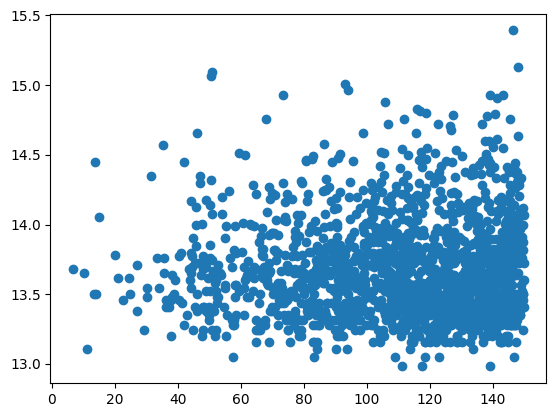

In [17]:
plt.figure()
plt.scatter(r[mask], logM[mask])
plt.show()

In [ ]:
r[:50]

array([349.24707, 146.40367, 353.74228, 379.646  , 311.05957, 395.80585,
       355.4183 , 220.7947 , 357.46536, 178.85849, 259.75156, 234.24883,
       327.489  , 198.69333, 242.48155, 378.26965, 390.1401 , 234.0676 ,
       305.52817, 298.48996, 276.35233, 407.69806, 382.937  , 363.99792,
       225.94995, 245.68578, 364.86862, 554.6506 , 383.55875, 377.03662,
       351.59308, 156.34087, 426.48044, 248.92621, 205.5791 , 536.3822 ,
       333.6161 , 315.71008, 260.74118, 248.16658, 448.7594 , 216.2631 ,
       258.0891 , 262.9471 , 328.025  , 219.90262, 285.4531 , 252.06532,
       273.13776, 366.21063], dtype=float32)

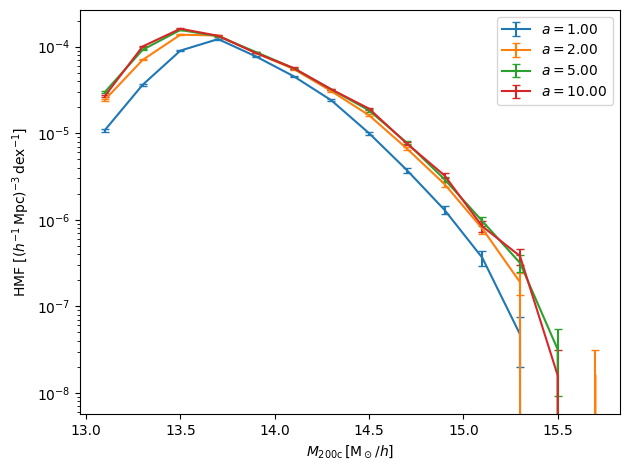

In [ ]:
plt.figure()


for i in range(len(a)):
    y, ey = data[i]
    plt.errorbar(x, y, yerr=ey, label=fr"$a = {a[i]:.2f}$", ls="-", capsize=3)


plt.legend()
plt.yscale("log")

plt.xlabel(r"$M_\mathrm{200c} \, [\mathrm{M}_\odot/h]$")
plt.ylabel(r"$\mathrm{HMF} ~ [(h^{-1}\,\mathrm{Mpc})^{-3} \, \mathrm{dex}^{-1}]$")
plt.tight_layout()
# plt.savefig("hmf_future_vs_past.png", dpi=300)

plt.show()

In [69]:
fname = "/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_MULTIBIN_N256_DES_V2/N256_future/step_0/output/snapdir_004/snapshot_004.hdf5"
# fname_cat = "/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_MULTIBIN_N256_DES_V2/N256_future/step_0/output/groups_004/groups_004.hdf5"
reader = csiborgtools.read.CSiBORG3Snapshot(0, 0, paths, fpath_override=fname)


fname_cat = "/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_MULTIBIN_N256_DES_V2/N256_future/step_0/output/groups_004/fof_subhalo_tab_004.hdf5"
reader_cat = csiborgtools.read.CSiBORG3Catalogue(0, 0, paths, fpath_override=fname_cat)


In [70]:
hids_all = reader.particle_halo_ids(False)

In [52]:
hids_all.max()

np.int32(41170)

In [74]:
import numpy as np
from scipy.integrate import quad
import astropy.units as u
from astropy.constants import c
from astropy.cosmology import Planck18  # or FlatLambdaCDM(...)
from astropy.cosmology import FlatLambdaCDM

cosmo = FlatLambdaCDM(H0=68.1, Om0=0.306)

def particle_horizon(a):
    """Proper distance to the particle horizon at scale factor a (dimensionless)."""
    def integrand(a_prime):
        return c.value / (cosmo.H(1/a_prime - 1).value * (a_prime**2))
    # integrate from a_ini ~ 0 to a
    chi, error = quad(integrand, 1e-8, a)
    return (a * chi) * u.Mpc  # proper distance

def event_horizon(a):
    """Proper distance to the event horizon at scale factor a."""
    def integrand(a_prime):
        return c.value / (cosmo.H(1/a_prime - 1).value * (a_prime**2))
    chi, error = quad(integrand, a, 1e3)  # integrate to large a
    return (a * chi) * u.Mpc

In [118]:
a = np.linspace(0.1, 10,  100)
z = 1.0 / a - 1.0

eh = [event_horizon(ai).value for ai in a]

In [119]:
vpec = 1000
dh = 2 * vpec / cosmo.H(z)

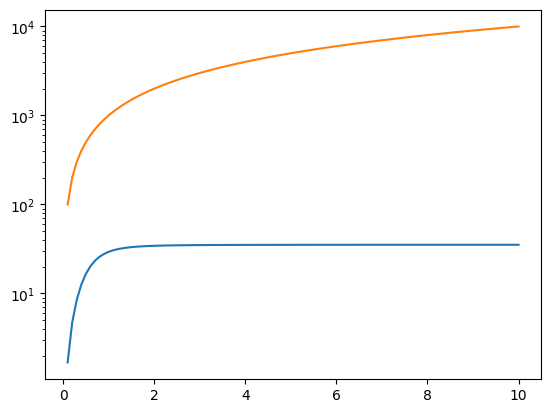

In [120]:
plt.figure()
plt.plot(a, dh)
plt.plot(a, a * 1000)
plt.yscale("log")
# plt.xscale("log")
plt.show()

In [43]:
pos = reader.halo_coordinates(500)

In [44]:
hids = reader.halo_particle_ids(500)

In [31]:
all_pos = reader.coordinates()
all_hids = reader.particle_ids()

2025-11-27 10:21:44,058 opening 32 blocks for snapshot `0`.


Reading block: 100%|██████████| 32/32 [00:04<00:00,  7.08it/s]


2025-11-27 10:21:48,680 opening 32 blocks for snapshot `0`.


Reading block: 100%|██████████| 32/32 [00:03<00:00,  9.44it/s]


In [45]:
dx = [np.linalg.norm(all_pos[np.where(hids[k] == all_hids)[0]] - pos[k]) for k in range(len(pos))]

In [46]:
dx

[np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float32(0.0),
 np.float3

In [47]:
np.nanmax(dx)

np.float32(0.0)

In [5]:
ps = reader.particle_ids()

2025-11-27 09:43:43,151 opening 32 blocks for snapshot `0`.


Reading block:   0%|          | 0/32 [00:00<?, ?it/s]

Reading block: 100%|██████████| 32/32 [00:03<00:00,  9.00it/s]


In [20]:


from tqdm import trange

lengths = []

for i in trange(100):
    pos = reader.halo_coordinates(i)
    lengths.append(len(pos))

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:17<00:00,  5.71it/s]


In [21]:
lengths = np.array(lengths)

In [22]:
reader_cat._read_fof_catalogue("GroupLen")[:100] == lengths

2025-11-27 09:48:09,979 opening 32 blocks for snapshot `0`.


Reading blocks:   0%|          | 0/32 [00:00<?, ?it/s]

Reading blocks: 100%|██████████| 32/32 [00:00<00:00, 143.67it/s]


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [10]:
reader_cat.coordinates

2025-11-27 09:45:09,099 opening 32 blocks for snapshot `0`.


Reading blocks:   0%|          | 0/32 [00:00<?, ?it/s]

Reading blocks: 100%|██████████| 32/32 [00:00<00:00, 174.27it/s]


array([[359.80267, 680.8848 , 264.55627],
       [224.59953, 294.54324, 263.9151 ],
       [340.29395, 568.29095, 611.22986],
       ...,
       [109.97198, 193.86703, 587.94556],
       [ 75.51574, 216.0668 , 576.58276],
       [116.90465, 423.54877, 622.02936]], dtype=float32)

In [ ]:
pos = reader.coordinates()

2025-11-27 06:26:47,951 opening 32 blocks for snapshot `0`.


Reading block:   0%|          | 0/32 [00:00<?, ?it/s]

Reading block: 100%|██████████| 32/32 [00:09<00:00,  3.42it/s]


In [ ]:
mass = reader.masses()

2025-11-26 10:14:36,106 opening 32 blocks for snapshot `0`.


Reading block:   0%|          | 0/32 [00:00<?, ?it/s]

Reading block: 100%|██████████| 32/32 [00:02<00:00, 11.46it/s]


In [ ]:
rho_gen = csiborgtools.field.DensityField(681, "PCS")

rho = rho_gen(pos, mass, grid=128)

Processing particles for the density field:   0%|          | 0/31 [00:00<?, ?it/s]

Processing particles for the density field:  97%|█████████▋| 30/31 [00:01<00:00, 22.93it/s]


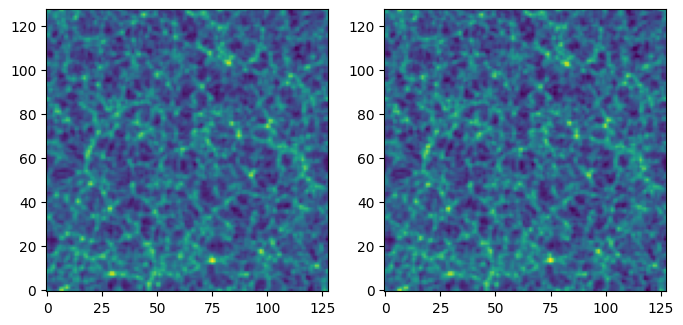

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6), ncols=2)
# plt.scatter(pos[:,0], pos[:,1], s=0.00001)
ax[0].imshow(np.log10(rho_future[:, :, 64].T), origin='lower', cmap='viridis', )
ax[1].imshow(np.log10(rho[:, :, 64].T), origin='lower', cmap='viridis', )
plt.show()

In [ ]:
dx = rho_future - rho


dx = dx.flatten()

low, high = np.percentile(dx, [1, 99])
dx = dx[(dx > low) & (dx < high)]

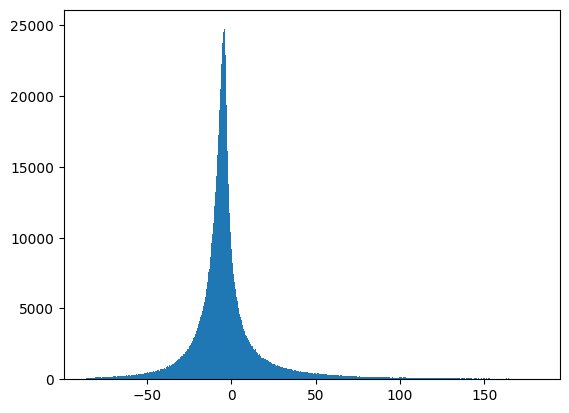

In [ ]:
plt.figure()
plt.hist(dx.flatten(), bins="auto")


plt.show()

In [ ]:
pos

array([[360.45456  , 680.2917   , 264.91858  ],
       [360.46487  , 680.3602   , 264.8978   ],
       [360.42346  , 680.3505   , 264.8656   ],
       ...,
       [678.93823  ,   5.25942  ,   1.1766163],
       [677.84344  ,   3.2074924,   3.3472073],
       [680.38055  ,   3.8725178,   2.7931101]], dtype=float32)

In [ ]:
mass = reader["totmass"]

2025-04-22 00:35:11,562 opening 32 blocks for snapshot `0`.


Reading blocks: 100%|██████████| 32/32 [00:00<00:00, 101.04it/s]


In [ ]:
reader["cartesian_pos"][0] / reader.boxsize

2025-04-22 00:35:12,599 opening 32 blocks for snapshot `0`.


Reading blocks: 100%|██████████| 32/32 [00:00<00:00, 177.35it/s]


array([0.47119924, 0.49639446, 0.5392125 ], dtype=float32)

In [ ]:
np.log10(mass)

array([14.547638 , 14.25489  , 14.140126 , 14.326363 , 14.008219 ,
       13.883847 , 13.792009 , 14.024103 , 13.723894 , 13.705482 ,
       13.629027 , 13.6187105, 13.590682 , 13.574805 , 13.563099 ,
       13.560719 , 13.755492 , 13.449866 , 13.8230915, 13.424499 ,
       13.414591 , 13.411237 , 13.427752 , 13.525957 , 13.437367 ,
       13.361344 , 13.353725 , 13.342039 , 13.33003  , 13.749354 ,
       13.3218355, 13.34597  , 13.365105 , 13.282918 , 13.27837  ,
       13.26913  , 13.2548895, 13.24513  , 13.849651 , 13.230065 ,
       13.219725 , 13.219725 , 13.21446  , 13.21446  , 13.203737 ,
       13.240166 , 13.192741 , 13.192741 , 13.18146  , 13.198274 ,
       13.157979 , 13.145745 , 13.133156 , 13.126721 , 13.099987 ,
       13.099987 , 13.18146  , 13.085977 , 13.085977 , 13.078798 ,
       13.078798 , 13.071499 , 13.071499 , 13.071499 , 13.071499 ,
       13.0640745, 13.048835 , 13.024923 , 13.024923 , 13.01665  ,
       12.990843 , 12.990843 , 12.981889 , 12.981889 , 13.3420

In [ ]:
nsnap = str(0).zfill(3)

reader_snapshot = csiborgtools.read.CSiBORG3Snapshot(
    0, 0, paths, fpath_override=f"/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_INNER_N128_DES_V2/resimulations/step_4/output/snapdir_{nsnap}/snapshot_{nsnap}.hdf5")

pos = reader_snapshot.coordinates()
mass = reader_snapshot.masses()

x0 = np.asarray([0.4700744,0.49677455,0.50836533]) * 340.5
r = np.linalg.norm(pos - x0, axis=1)

2025-04-22 00:38:56,047 opening 32 blocks for snapshot `0`.


Reading block:  50%|█████     | 16/32 [00:01<00:01,  9.86it/s]

Reading block: 100%|██████████| 32/32 [00:03<00:00,  9.35it/s]


2025-04-22 00:38:59,490 opening 32 blocks for snapshot `0`.


Reading block: 100%|██████████| 32/32 [00:03<00:00, 10.02it/s]


In [ ]:
len(pos)**(1/3)

128.97423518451512

In [ ]:
m_high = np.unique(mass).min()

mask = mass == m_high

mask2 = ~mask & (r < 50)

In [ ]:
np.unique(mass)

array([1.9982359e+11, 1.5985887e+12], dtype=float32)

In [ ]:
np.mean(pos[mask], axis=0)

array([172.4056 , 168.44812, 170.04256], dtype=float32)

In [ ]:
x0

array([160.0603332 , 169.15173427, 173.09839486])

In [ ]:
mask.sum()**(1/3)

np.float64(38.06268508766835)

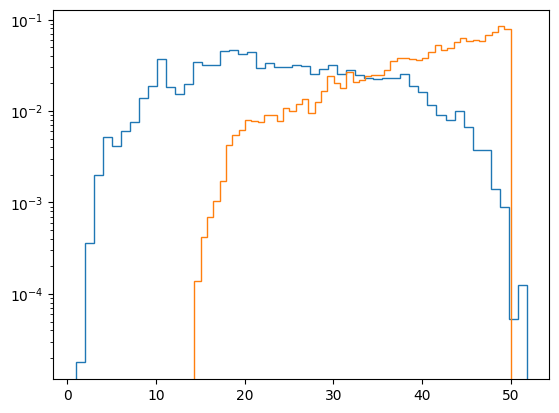

In [ ]:
plt.figure()
plt.hist(r[mask], bins=50, density=1, histtype="step", label="high mass")
plt.hist(r[mask2], bins=50, density=1, histtype="step", label="low mass")
plt.yscale("log")

plt.show()

In [ ]:
1 / 200**0.5 * 340.5

24.076985899401944

In [ ]:
def load_and_convert_to_xyz(filename="2MPP.txt"):
    from astropy.cosmology import FlatLambdaCDM

    cosmo = FlatLambdaCDM(H0=100, Om0=0.306)
    data = np.loadtxt(filename)

    ra = data[:, 1]  # radians
    dec = data[:, 2]  # radians
    zo = data[:, 3]

    comoving_dist = cosmo.comoving_distance(zo).value 
    X = np.vstack([comoving_dist, np.rad2deg(ra), np.rad2deg(dec)]).T
    return csiborgtools.radec_to_cartesian(X)

pos_2mpp = load_and_convert_to_xyz()

pos_virgo = csiborgtools.clusters["Virgo"].cartesian_pos(681.1) - 681.1 / 2
# pos_fornax = csiborgtools.clusters["Fornax"].cartesian_pos(681.1) - 681.1 / 2

# pos_2mpp_box = pos_2mpp[np.all(np.abs(pos_2mpp) < 25, axis=1)]
pos_2mpp_box = pos_2mpp - pos_virgo
pos_virgo = pos_virgo - pos_virgo
# pos_fornax = pos_fornax - pos_virgo

pos_2mpp_box = pos_2mpp_box[np.all(np.abs(pos_2mpp_box) < 15., axis=1)]


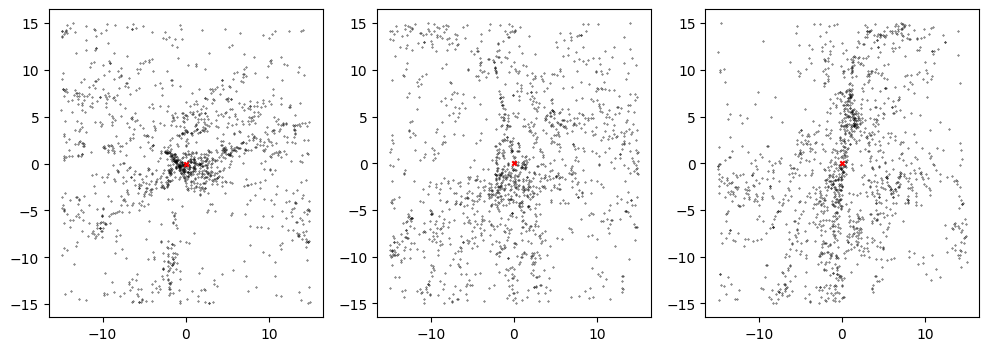

In [ ]:
kwargs = dict(s=0.1, c="black")
kwargs_virgo = dict(s=10, c="red", marker="x")
kwargs_fornax = dict(s=10, c="blue", marker="x")

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

for n, ax in enumerate(axs):
    if n == 0:
        ax.scatter(pos_2mpp_box[:, 2], pos_2mpp_box[:, 1], **kwargs)
        ax.scatter(pos_virgo[2], pos_virgo[1], **kwargs_virgo)
        # ax.scatter(pos_fornax[2], pos_fornax[1], **kwargs_fornax)
    elif n == 1:
        ax.scatter(pos_2mpp_box[:, 2], pos_2mpp_box[:, 0], **kwargs)
        ax.scatter(pos_virgo[2], pos_virgo[0], **kwargs_virgo)
        # ax.scatter(pos_fornax[2], pos_fornax[0], **kwargs_fornax)
    elif n == 2:
        ax.scatter(pos_2mpp_box[:, 1], pos_2mpp_box[:, 0], **kwargs)
        ax.scatter(pos_virgo[1], pos_virgo[0], **kwargs_virgo)
        # ax.scatter(pos_fornax[1], pos_fornax[0], **kwargs_fornax)


fig.show()



In [ ]:
nsnap = "130"
# f = f"/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_INNER_N128_DES_V2/resimulations/step_4/output/groups_{nsnap}/fof_subhalo_tab_{nsnap}.hdf5"
f = "/mnt/home/rstiskalek/ceph/CSiBORG/RANDOM_N1024_L1000/step_0/output/groups_130/fof_subhalo_tab_130.hdf5"
# reader = csiborgtools.read.CSiBORG3Catalogue(0, 0, paths, fpath_override=f, boxsize=340.5)
reader = csiborgtools.read.CSiBORG3Catalogue(0, 0, paths, fpath_override=f, boxsize=1000)

In [ ]:
pos = reader["cartesian_pos"] - reader.boxsize / 2
mass = np.log10(reader["totmass"])
r = reader["dist"]
cont = reader["GroupContamination"]

pmax = 25

2025-04-06 18:48:29,675 opening 32 blocks for snapshot `0`.


Reading blocks:   0%|          | 0/32 [00:00<?, ?it/s]

Reading blocks: 100%|██████████| 32/32 [00:00<00:00, 170.50it/s]


2025-04-06 18:48:29,872 opening 32 blocks for snapshot `0`.


Reading blocks: 100%|██████████| 32/32 [00:00<00:00, 199.27it/s]


2025-04-06 18:48:30,038 opening 32 blocks for snapshot `0`.


Reading blocks: 100%|██████████| 32/32 [00:00<00:00, 187.78it/s]


2025-04-06 18:48:30,237 opening 32 blocks for snapshot `0`.


Reading blocks: 100%|██████████| 32/32 [00:00<00:00, 163.90it/s]


### Group contamination

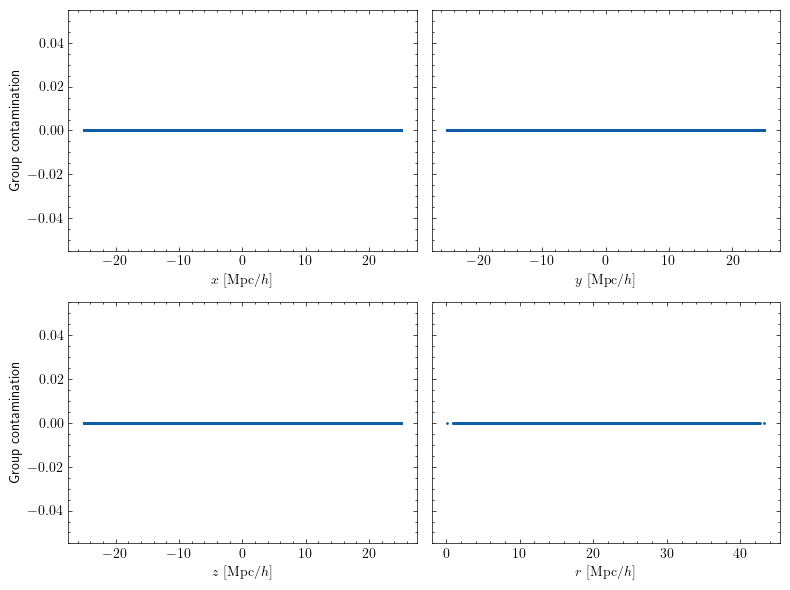

In [ ]:
m = np.all(np.abs(pos) < pmax, axis=1)

x = pos[m, 0]
y = pos[m, 1]
z = pos[m, 2]
c = cont[m]
r = reader["dist"][m]

with plt.style.context("science"):
    fig, axs = plt.subplots(2, 2, figsize=(8, 6), sharey=True)

    axs[0, 0].scatter(x, c, s=1)
    axs[0, 0].set_xlabel(r"$x ~ [\mathrm{Mpc} / h]$")
    axs[0, 0].set_ylabel("Group contamination")

    axs[0, 1].scatter(y, c, s=1)
    axs[0, 1].set_xlabel(r"$y ~ [\mathrm{Mpc} / h]$")

    axs[1, 0].scatter(z, c, s=1)
    axs[1, 0].set_xlabel(r"$z ~ [\mathrm{Mpc} / h]$")
    axs[1, 0].set_ylabel(r"Group contamination")

    axs[1, 1].scatter(r, c, s=1)
    axs[1, 1].set_xlabel(r"$r ~ [\mathrm{Mpc} / h]$")

    fig.tight_layout()
    # fig.savefig("group_contamination.png", dpi=300)
    fig.show()

### Halo mass function

In [ ]:
def get_HMF(mass, box_length, dlog=0.2, log_mass_bins=None, mask_zeros=True):
    """
    Calculate the halo mass function defined as the number of haloes per
    logarithmic mass interval `dlog` per volume.

    Unless `log_mass_bins` is provided, the mass bins are created from
    `log_mass.min()` to `log_mass.max()` with a step of `dlog`.
    """
    if mask_zeros:
        mass = mass[mass > 0]

    log_mass = np.log10(mass)
    if log_mass_bins is None:
        bins = np.arange(log_mass.min(), log_mass.max() + dlog, dlog)
    else:
        bins = log_mass_bins

    xrange = (bins.min(), bins.max())
    counts, _ = np.histogram(log_mass, bins=bins, range=xrange)
    counts = counts.astype(float)

    volume = box_length**3

    counts /= volume * dlog
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    return bin_centers, counts


from colossus.cosmology import cosmology
from colossus.lss import mass_function

cosmo_params={'flat': True, 'H0': 68.11, 'Om0': 0.306,
              'Ob0': 0.0486, 'sigma8': 0.8213, 'ns': 0.967}

# Next, get the HMF from colossus and create its interpolant.
cosmology.addCosmology("myCosmo", **cosmo_params)
cosmology.setCosmology("myCosmo")

x_theory = np.logspace(9., 16, 10000)
y_theory = mass_function.massFunction(
    x_theory, 0.0, mdef="fof", model="angulo12", q_out="dndlnM",) * np.log(10)
y_theory_rockstar = mass_function.massFunction(
    x_theory, 0.0, mdef="200c", model="tinker08", q_out="dndlnM",) * np.log(10)

In [ ]:
np.sum(np.log10(M) > 14.9)

np.int64(641)

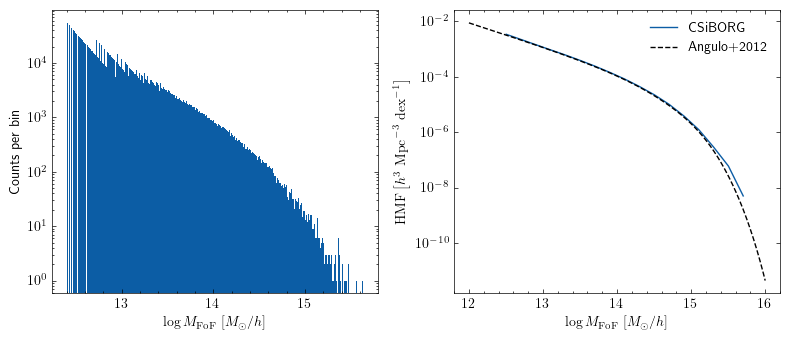

In [ ]:
# m = np.all(np.abs(pos) < pmax, axis=1)
M = reader["totmass"]

x, y = get_HMF(M, box_length=1000, dlog=0.2)

with plt.style.context("science"):
    fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), sharey=False)
    axs[0].hist(np.log10(M), bins="auto")
    axs[0].set_yscale("log")
    axs[0].set_xlabel(r"$\log M_{\mathrm{FoF}}~[M_\odot / h]$")
    axs[0].set_ylabel(r"Counts per bin")
    
    axs[1].plot(x, y, label=r"CSiBORG")
    axs[1].plot(np.log10(x_theory), y_theory, label=r"Angulo+2012", linestyle="--", 
                color="black")

    axs[1].set_yscale("log")
    axs[1].set_xlabel(r"$\log M_{\mathrm{FoF}}~[M_\odot / h]$")
    axs[1].set_ylabel(r"$\mathrm{HMF} \left[ h^3~\mathrm{Mpc}^{-3}~\mathrm{dex}^{-1} \right]$")
    axs[1].legend()

    fig.tight_layout()
    # fig.savefig("HMF_FOF.png", dpi=300)
    fig.show()

In [ ]:
reader_rockstar = csiborgtools.read.ReaderRockstar(
    "/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_INNER_N128_DES_V2/resimulations/step_4/output/Rockstar/", 130)

Mvir = reader_rockstar["M200c"]

pos_rock = reader_rockstar["pos"] - reader.boxsize / 2
m_rock = np.all(np.abs(pos_rock) < pmax, axis=1) & (Mvir > 0)

Reading a Rockstar catalogue from `/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_INNER_N128_DES_V2/resimulations/step_4/output/Rockstar/out_130.list`.


IndexError: boolean index did not match indexed array along axis 0; size of axis is 1229221 but size of corresponding boolean axis is 586315

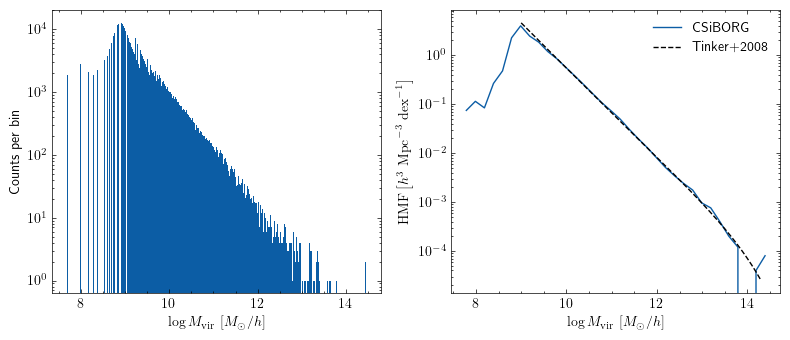

In [ ]:
x, y = get_HMF(Mvir[m_rock], box_length=50, dlog=0.2)

with plt.style.context("science"):
    fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), sharey=False)
    axs[0].hist(np.log10(Mvir[m_rock]), bins="auto")
    axs[0].set_yscale("log")
    axs[0].set_xlabel(r"$\log M_{\mathrm{vir}}~[M_\odot / h]$")
    axs[0].set_ylabel(r"Counts per bin")

    axs[1].plot(x, y, label=r"CSiBORG")
    axs[1].plot(np.log10(x_theory), y_theory_rockstar, label=r"Tinker+2008", linestyle="--", 
                color="black")

    axs[1].set_yscale("log")
    axs[1].set_xlabel(r"$\log M_{\mathrm{vir}}~[M_\odot / h]$")
    axs[1].set_ylabel(r"$\mathrm{HMF} \left[ h^3~\mathrm{Mpc}^{-3}~\mathrm{dex}^{-1} \right]$")
    axs[1].legend()

    fig.tight_layout()
    # fig.savefig("HMF_rockstar.png", dpi=300)
    fig.show()

### Check Virgo is present

In [ ]:
m = reader["totmass"] > 1e12

prob_match = csiborgtools.match.MatchingProbability(reader["cartesian_pos"][m], np.log10(reader["totmass"][m]),)

cl = csiborgtools.clusters["Virgo"]
ref_pos = cl.cartesian_pos(reader.boxsize)
ref_log_mass = 14.5
cdf, indxs = prob_match.match_halo(ref_pos, ref_log_mass, verbose=True)
cdf, indxs

pos_virgo = reader["cartesian_pos"][m][indxs]

NameError: name 'reader' is not defined

### Make a cutout around Virgo cluster

In [ ]:
reader_snapshot = csiborgtools.read.CSiBORG3Snapshot(
    0, 0, paths, fpath_override="/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_INNER_N128_DES_V2/resimulations/step_4/output/snapdir_130/snapshot_130.hdf5")

pos = reader_snapshot.coordinates()
mass = reader_snapshot.masses()

2025-04-08 23:24:09,988 opening 32 blocks for snapshot `0`.


Reading block: 100%|██████████| 32/32 [01:40<00:00,  3.14s/it]


2025-04-08 23:25:54,762 opening 32 blocks for snapshot `0`.


Reading block: 100%|██████████| 32/32 [00:18<00:00,  1.76it/s]


In [ ]:
# boxsize = 340.5
boxsize = 340.5
pos_virgo = [boxsize / 2, boxsize / 2, boxsize / 2]
mask_width = 50

mask_box = csiborgtools.read.find_boxed(pos, pos_virgo, mask_width, boxsize)

In [ ]:
pos_box = pos[mask_box]
mass_box = mass[mask_box]
pos_box -= np.min(pos_box, axis=0)
ax = 2

density_obj = csiborgtools.field.DensityField(mask_width, "TSC")
rho = density_obj.density_2d(pos_box, mass_box, ax, grid=2048, verbose=True)



Using TSC mass assignment scheme with weights
Time taken = 11.050 seconds



In [ ]:
def load_and_convert_to_xyz(filename="2MPP.txt"):
    from astropy.cosmology import FlatLambdaCDM

    cosmo = FlatLambdaCDM(H0=100, Om0=0.306)
    data = np.loadtxt(filename)

    ra = data[:, 1]  # radians
    dec = data[:, 2]  # radians
    zo = data[:, 3]

    comoving_dist = cosmo.comoving_distance(zo).value 
    X = np.vstack([comoving_dist, np.rad2deg(ra), np.rad2deg(dec)]).T
    return csiborgtools.radec_to_cartesian(X)

pos_2mpp = load_and_convert_to_xyz()
pos_2mpp_box = pos_2mpp[np.all(np.abs(pos_2mpp) < 25, axis=1)]

Saving inner_high_2.png


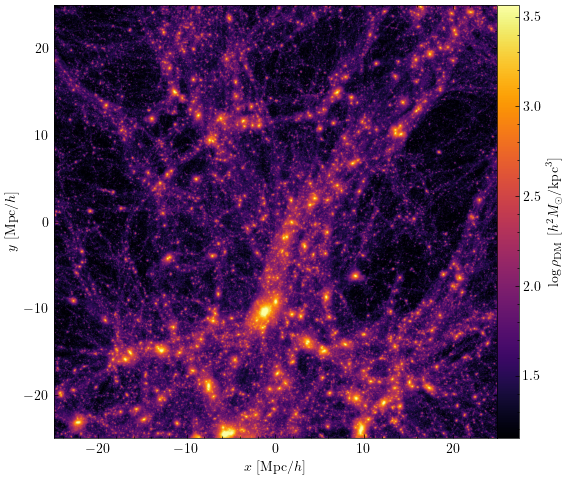

Saving inner_high_2_galaxies.png


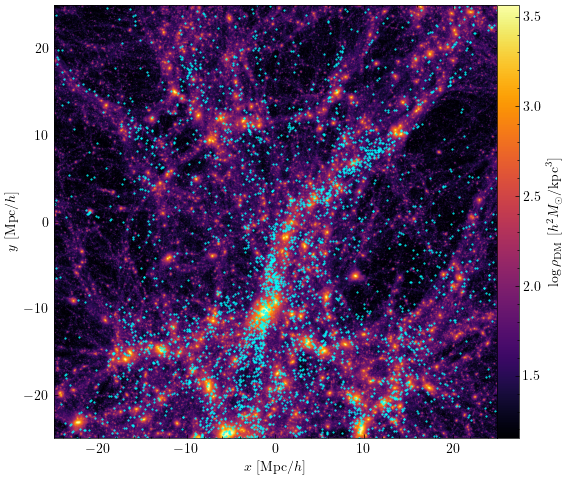

In [ ]:
extent = (-mask_width / 2, mask_width / 2, -mask_width / 2, mask_width / 2)

img = np.log10(1 + rho)
vmin = 1.15
label = r"$\log \rho_{\rm DM} ~ [h^2 M_\odot / \mathrm{kpc}^3]$"
vmax = np.percentile(img.flatten(), 99.9)

def make_plot(with_galaxies=False):
    with plt.style.context("science"):
        plt.figure(figsize=(6, 5))
        plt.imshow(img, extent=extent, origin="lower", aspect="auto",
                   cmap="inferno", vmin=vmin, vmax=vmax)
        
        plt.colorbar(label=label, pad=0)
        plt.xlabel(r"$x ~ [\mathrm{Mpc} / h]$")
        plt.ylabel(r"$y ~ [\mathrm{Mpc} / h]$")

        if with_galaxies and pos_2mpp_box is not None and ax is not None:
            kwargs = dict(s=0.25, c="cyan")
            if ax == 0:
                plt.scatter(pos_2mpp_box[:, 2], pos_2mpp_box[:, 1], **kwargs)
            elif ax == 1:
                plt.scatter(pos_2mpp_box[:, 2], pos_2mpp_box[:, 0], **kwargs)
            elif ax == 2:
                plt.scatter(pos_2mpp_box[:, 1], pos_2mpp_box[:, 0], **kwargs)

        plt.tight_layout()
        filename = f"inner_high_{ax}.png"
        if with_galaxies:
            filename = filename.replace(".png", "_galaxies.png")
        print(f"Saving {filename}")
        plt.savefig(filename, dpi=500)
        plt.show()

make_plot(with_galaxies=False)
make_plot(with_galaxies=True)
